# Quickstart

In [1]:
from immunowave import models, spatial
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

## Define a model

In [2]:
model = models.FHNB(
    α=1.0,
    θ=0.1,
    η=0.2,
    ρ=0.0,
    ε=0.0,
    ξ=1.0,
    λ=0.5,
    μ=1.0,
)
model

FHNB(α=1.0, θ=0.1, η=0.2, ρ=0.0, ε=0.0, ξ=1.0, λ=0.5, μ=1.0, n_components=3)

## Initialize fields

Spatial discretization

In [3]:
L = 100.0
n = 100

shape = (n,)
lb = [-L / 2]
h = L / (n - 1)

In [4]:
A = spatial.ScalarField(shape, lb, h, 0)
R = spatial.ScalarField(shape, lb, h, 0)
B = spatial.ScalarField(
    shape, lb, h, fn=lambda x: jnp.where(jnp.abs(x) < h / 2, 1 / h, 0)
)

B.integral()

Array(1., dtype=float64)

## Define time domain

In [5]:
t0 = 0.0
t1 = 50.0
t = np.linspace(t0, t1, 20)

## Solve

In [6]:
state0 = (A, R, B)

In [7]:
solution = model.solve(state0, t=t, dt0=1e-2, rtol=1e-8, atol=1e-8, max_steps=100000)

In [8]:
solution

Solution(
  t0=f64[],
  t1=f64[],
  ts=f64[20],
  ys=(
    ScalarField(
      ndim=1,
      lb=f64[1](numpy),
      ub=f64[1](numpy),
      h=1.0101010101010102,
      values=f64[20,100]
    ),
    ScalarField(
      ndim=1,
      lb=f64[1](numpy),
      ub=f64[1](numpy),
      h=1.0101010101010102,
      values=f64[20,100]
    ),
    ScalarField(
      ndim=1,
      lb=f64[1](numpy),
      ub=f64[1](numpy),
      h=1.0101010101010102,
      values=f64[20,100]
    )
  ),
  interpolation=None,
  stats={
    'max_steps':
    100000,
    'num_accepted_steps':
    i64[],
    'num_rejected_steps':
    i64[],
    'num_steps':
    i64[]
  },
  result=i64[],
  solver_state=None,
  controller_state=None,
  made_jump=None
)

## Plot

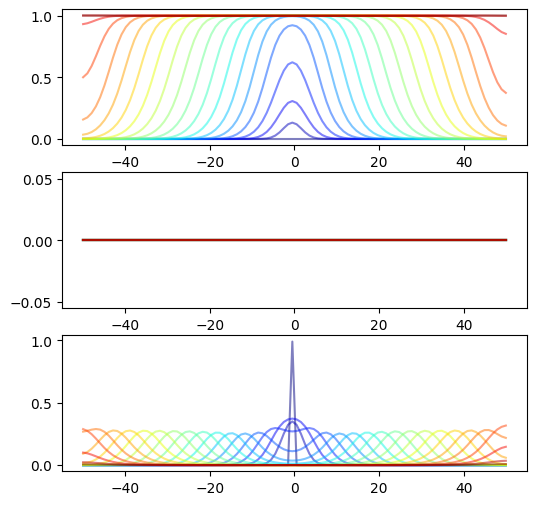

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(6, 2 * 3))
import matplotlib.pylab as pl

colors = pl.cm.jet(np.linspace(0, 1, len(t)))
for i in range(len(t)):
    for j in range(3):
        axes[j].plot(
            solution.ys[j].domain[0],
            solution.ys[j].values[i],
            alpha=0.5,
            color=colors[i],
        )
plt.show()